ABC-XYZ АНАЛИЗ С АДАПТИВНЫМИ ПОРОГАМИ
ШВЕЙНОЕ ПРОИЗВОДСТВО - ПРАВИЛЬНЫЙ ПОДХОД

📂 Загрузка данных...
✅ Данные загружены, моделей: 108

1. ABC-АНАЛИЗ (ВЫРУЧКА)

📊 ABC-РАСПРЕДЕЛЕНИЕ:
   • A: 69 моделей (63.9%), выручка: 543.5M руб.
   • B: 24 моделей (22.2%), выручка: 154.2M руб.
   • C: 15 моделей (13.9%), выручка: 80.5M руб.

2. XYZ-АНАЛИЗ (АДАПТИВНЫЕ ПОРОГИ)
   • Период анализа: 53 недель

📊 Статистика CV:
   • Минимум: 18.0%
   • 33-й перцентиль: 23.7%
   • 67-й перцентиль: 26.1%
   • Максимум: 36.4%

📊 АДАПТИВНЫЕ ПОРОГИ XYZ:
   • X (самые стабильные): CV <= 23.7%
   • Y (средние): 23.7% < CV <= 26.1%
   • Z (нестабильные): CV > 26.1%

📊 XYZ-РАСПРЕДЕЛЕНИЕ:
   • X: 36 моделей (33.3%), CV: 18.0% - 23.6%
   • Y: 36 моделей (33.3%), CV: 23.7% - 26.1%
   • Z: 36 моделей (33.3%), CV: 26.1% - 36.4%

3. МАТРИЦА ABC-XYZ (АДАПТИВНАЯ)

📊 МАТРИЦА ABC-XYZ (количество моделей):
xyz   X   Y   Z
abc            
A    30  24  15
B     4   9  11
C     2   3  10

📊 МАТРИЦА ABC-XYZ (доля в %):
xyz     X 

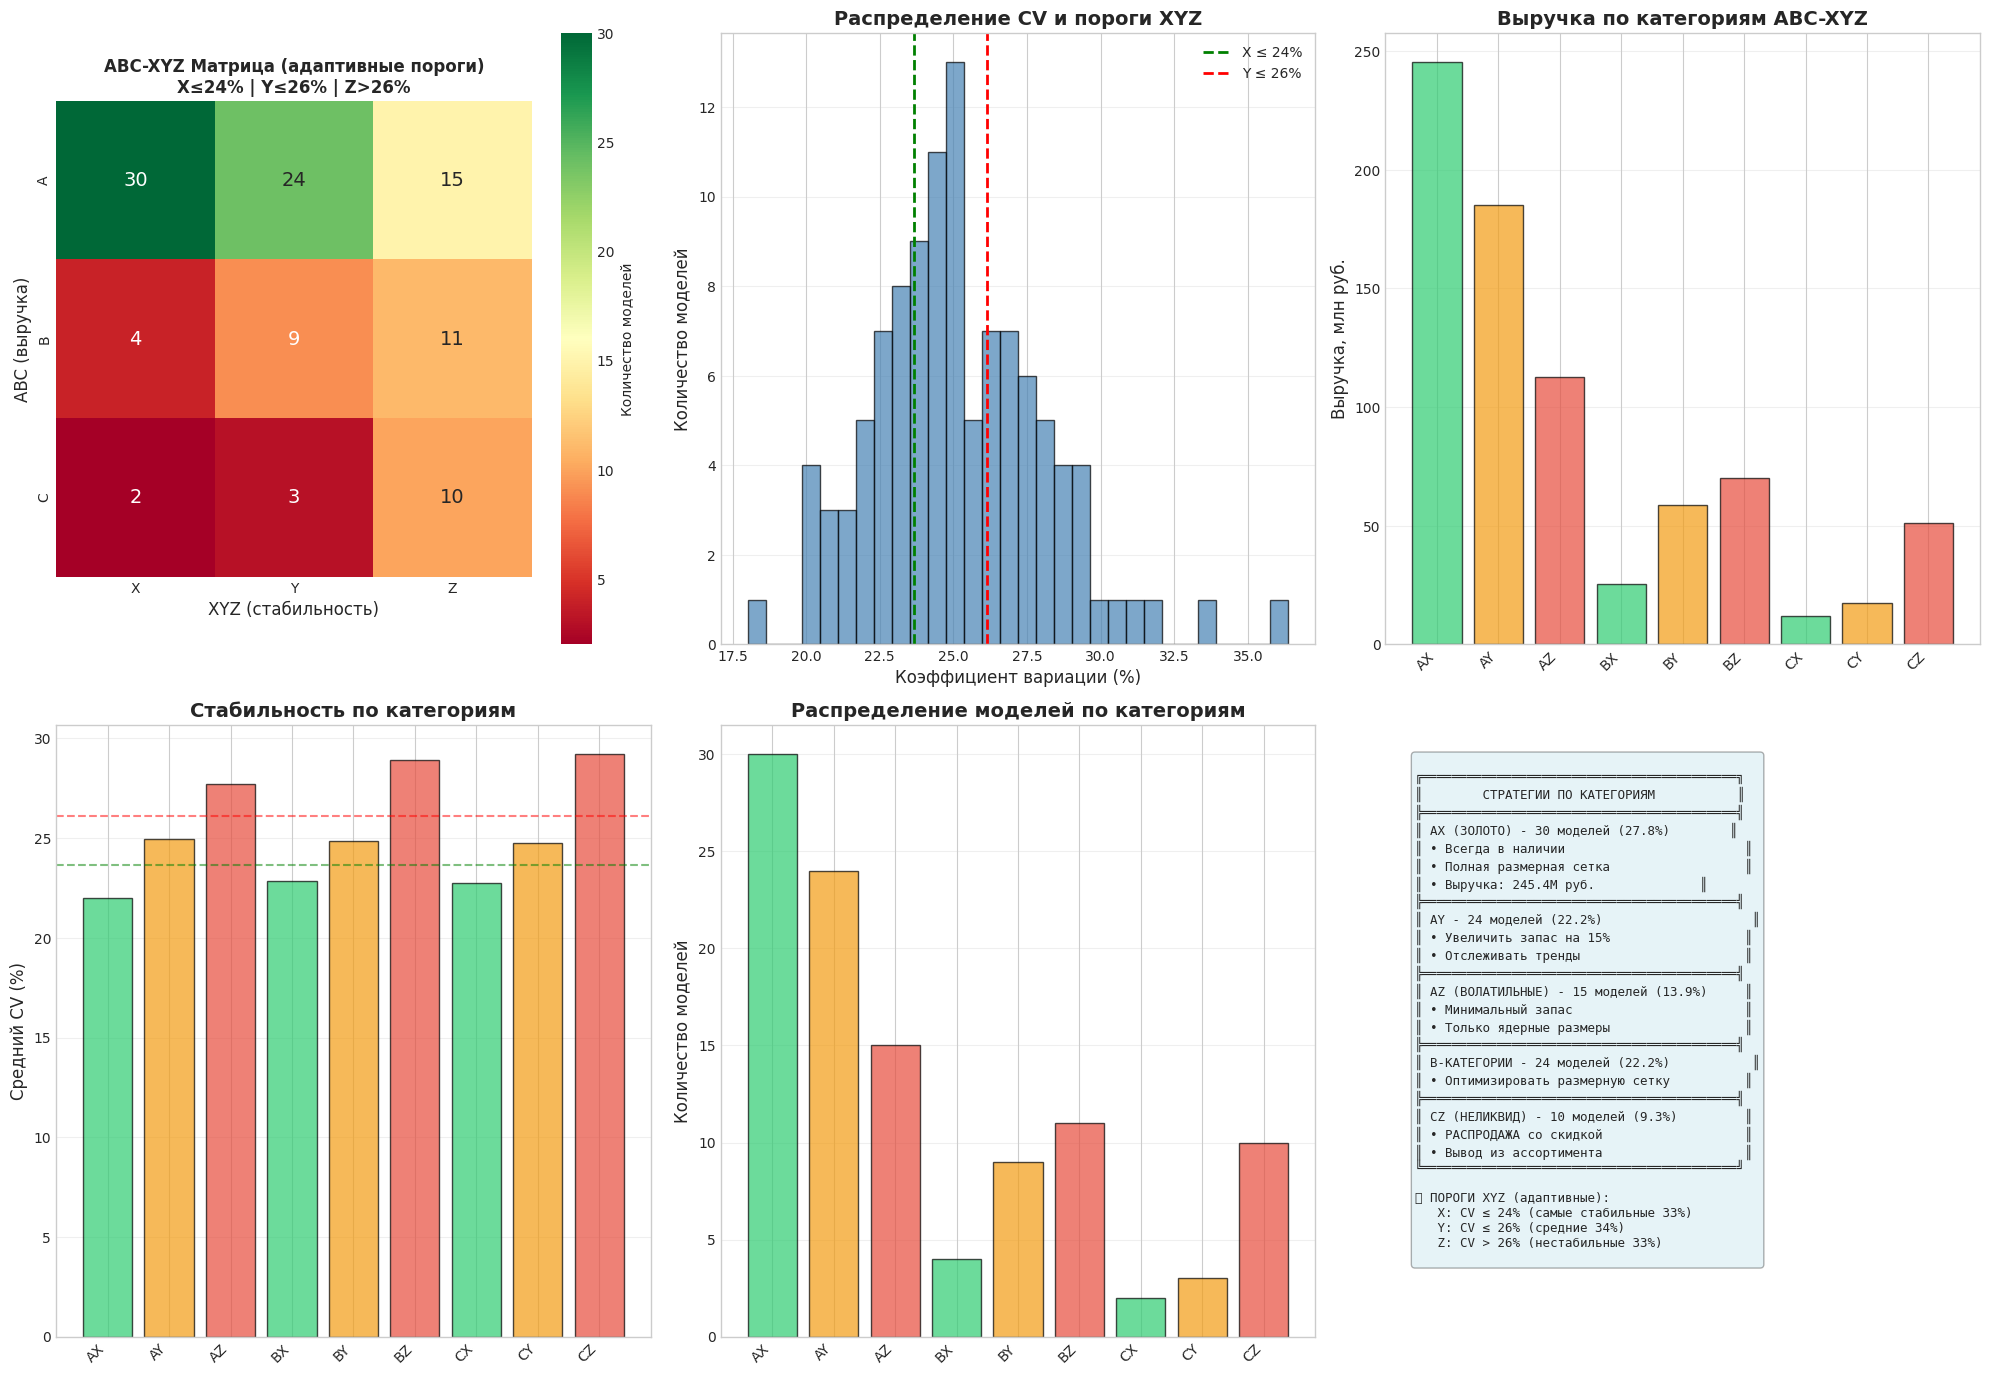

✅ Визуализация сохранена: abc_xyz_adaptive.png

5. ИТОГИ АНАЛИЗА

📊 КЛЮЧЕВЫЕ РЕЗУЛЬТАТЫ:

1. АДАПТИВНЫЕ ПОРОГИ XYZ:
   • X (стабильные): CV <= 23.7% → 36 моделей
   • Y (средние): 23.7% < CV <= 26.1% → 36 моделей
   • Z (нестабильные): CV > 26.1% → 36 моделей

2. РАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИЯМ:

   • AX:  30 моделей (27.8%)
   • AY:  24 моделей (22.2%)
   • AZ:  15 моделей (13.9%)
   • BX:   4 моделей ( 3.7%)
   • BY:   9 моделей ( 8.3%)
   • BZ:  11 моделей (10.2%)
   • CX:   2 моделей ( 1.9%)
   • CY:   3 моделей ( 2.8%)
   • CZ:  10 моделей ( 9.3%)

3. ФИНАНСОВЫЙ РЕЗУЛЬТАТ:
   • AX (золото): 245.4M руб.
   • AZ (волатильные): 112.8M руб.
   • CZ (неликвид): 51.2M руб.

✅ Результаты сохранены: abc_xyz_adaptive_models.csv

✅ АНАЛИЗ УСПЕШНО ЗАВЕРШЕН!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['font.family'] = 'DejaVu Sans'

print("=" * 80)
print("ABC-XYZ АНАЛИЗ С АДАПТИВНЫМИ ПОРОГАМИ")
print("ШВЕЙНОЕ ПРОИЗВОДСТВО - ПРАВИЛЬНЫЙ ПОДХОД")
print("=" * 80)

# ============================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================
print("\n📂 Загрузка данных...")

articles = pd.read_csv('articles.csv', sep=';', encoding='utf-8', decimal=',')
transactions = pd.read_csv('transactions.csv', sep=';', encoding='utf-8', decimal=',')
stock = pd.read_csv('stock.csv', sep=';', encoding='utf-8', decimal=',')

transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
transactions['month'] = transactions['t_dat'].dt.to_period('M')
transactions['week'] = transactions['t_dat'].dt.to_period('W')

articles['size'] = articles['size'].astype(str)
transactions['size'] = transactions['size'].astype(str)

# Создаем модели
articles['model_id'] = articles['product_type_name'] + '_' + articles['colour_group_name']
transactions['model_id'] = transactions['product_type_name'] + '_' + transactions['colour_group_name']

print(f"✅ Данные загружены, моделей: {articles['model_id'].nunique()}")

# ============================================
# 2. ABC-АНАЛИЗ ПО ВЫРУЧКЕ
# ============================================
print("\n" + "=" * 80)
print("1. ABC-АНАЛИЗ (ВЫРУЧКА)")
print("=" * 80)

model_revenue = transactions.groupby('model_id').agg({
    'price': 'sum',
    'margin': 'sum',
    'article_id': 'count',
    'product_type_name': 'first',
    'colour_group_name': 'first'
}).rename(columns={'price': 'revenue', 'margin': 'total_margin', 'article_id': 'sales_count'})

model_revenue = model_revenue.sort_values('revenue', ascending=False).reset_index()
model_revenue['revenue_cumsum_pct'] = model_revenue['revenue'].cumsum() / model_revenue['revenue'].sum() * 100

def abc_classify(pct):
    if pct <= 70:
        return 'A'
    elif pct <= 90:
        return 'B'
    else:
        return 'C'

model_revenue['abc'] = model_revenue['revenue_cumsum_pct'].apply(abc_classify)

print(f"\n📊 ABC-РАСПРЕДЕЛЕНИЕ:")
for cat in ['A', 'B', 'C']:
    cat_data = model_revenue[model_revenue['abc'] == cat]
    print(f"   • {cat}: {len(cat_data)} моделей ({len(cat_data)/len(model_revenue)*100:.1f}%), "
          f"выручка: {cat_data['revenue'].sum()/1_000_000:.1f}M руб.")

# ============================================
# 3. XYZ-АНАЛИЗ С АДАПТИВНЫМИ ПОРОГАМИ
# ============================================
print("\n" + "=" * 80)
print("2. XYZ-АНАЛИЗ (АДАПТИВНЫЕ ПОРОГИ)")
print("=" * 80)

# Используем НЕДЕЛЬНЫЕ продажи
weekly_sales = transactions.groupby(['model_id', 'week']).size().unstack(fill_value=0)

print(f"   • Период анализа: {len(weekly_sales.columns)} недель")

# Рассчитываем CV для каждой модели
cv_list = []
for model_id in weekly_sales.index:
    sales = weekly_sales.loc[model_id].values
    mean_sales = sales.mean()

    if mean_sales > 0 and sales.sum() >= 5:
        cv = (sales.std() / mean_sales) * 100
    else:
        cv = np.nan

    cv_list.append({'model_id': model_id, 'cv': cv})

cv_df = pd.DataFrame(cv_list)
cv_df = cv_df.dropna(subset=['cv'])

print(f"\n📊 Статистика CV:")
print(f"   • Минимум: {cv_df['cv'].min():.1f}%")
print(f"   • 33-й перцентиль: {cv_df['cv'].quantile(0.33):.1f}%")
print(f"   • 67-й перцентиль: {cv_df['cv'].quantile(0.67):.1f}%")
print(f"   • Максимум: {cv_df['cv'].max():.1f}%")

# АДАПТИВНЫЕ ПОРОГИ НА ОСНОВЕ ПЕРЦЕНТИЛЕЙ
p33 = cv_df['cv'].quantile(0.33)
p67 = cv_df['cv'].quantile(0.67)

def classify_xyz_adaptive(cv):
    """
    Адаптивная XYZ классификация на основе перцентилей:
    - X: нижние 33% (самые стабильные)
    - Y: средние 34% (средняя стабильность)
    - Z: верхние 33% (самые нестабильные)
    """
    if pd.isna(cv):
        return 'Z'
    if cv <= p33:
        return 'X'
    elif cv <= p67:
        return 'Y'
    else:
        return 'Z'

cv_df['xyz'] = cv_df['cv'].apply(classify_xyz_adaptive)

print(f"\n📊 АДАПТИВНЫЕ ПОРОГИ XYZ:")
print(f"   • X (самые стабильные): CV <= {p33:.1f}%")
print(f"   • Y (средние): {p33:.1f}% < CV <= {p67:.1f}%")
print(f"   • Z (нестабильные): CV > {p67:.1f}%")

print(f"\n📊 XYZ-РАСПРЕДЕЛЕНИЕ:")
for cat in ['X', 'Y', 'Z']:
    cat_data = cv_df[cv_df['xyz'] == cat]
    if len(cat_data) > 0:
        print(f"   • {cat}: {len(cat_data)} моделей ({len(cat_data)/len(cv_df)*100:.1f}%), "
              f"CV: {cat_data['cv'].min():.1f}% - {cat_data['cv'].max():.1f}%")

# ============================================
# 4. ОБЪЕДИНЯЕМ ABC + XYZ
# ============================================
print("\n" + "=" * 80)
print("3. МАТРИЦА ABC-XYZ (АДАПТИВНАЯ)")
print("=" * 80)

model_analysis = model_revenue.merge(cv_df[['model_id', 'cv', 'xyz']], on='model_id', how='left')
model_analysis['xyz'] = model_analysis['xyz'].fillna('Z')
model_analysis['abc_xyz'] = model_analysis['abc'] + model_analysis['xyz']

matrix = pd.crosstab(model_analysis['abc'], model_analysis['xyz'])
for abc in ['A', 'B', 'C']:
    if abc not in matrix.index:
        matrix.loc[abc] = 0
for xyz in ['X', 'Y', 'Z']:
    if xyz not in matrix.columns:
        matrix[xyz] = 0
matrix = matrix.reindex(['A', 'B', 'C'])[['X', 'Y', 'Z']]

print("\n📊 МАТРИЦА ABC-XYZ (количество моделей):")
print(matrix.to_string())

print("\n📊 МАТРИЦА ABC-XYZ (доля в %):")
matrix_pct = (matrix / matrix.sum().sum() * 100).round(1)
print(matrix_pct.to_string())

# ============================================
# 5. ВИЗУАЛИЗАЦИЯ
# ============================================
print("\n" + "=" * 80)
print("4. ВИЗУАЛИЗАЦИЯ")
print("=" * 80)

fig = plt.figure(figsize=(20, 14))

# 5.1 Матрица ABC-XYZ
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(matrix, annot=True, fmt='d', cmap='RdYlGn', ax=ax1,
            cbar_kws={'label': 'Количество моделей'}, square=True,
            annot_kws={'size': 14})
ax1.set_title(f'ABC-XYZ Матрица (адаптивные пороги)\nX≤{p33:.0f}% | Y≤{p67:.0f}% | Z>{p67:.0f}%',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('XYZ (стабильность)', fontsize=12)
ax1.set_ylabel('ABC (выручка)', fontsize=12)

# 5.2 Распределение CV
ax2 = plt.subplot(2, 3, 2)
ax2.hist(cv_df['cv'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=p33, color='green', linestyle='--', linewidth=2, label=f'X ≤ {p33:.0f}%')
ax2.axvline(x=p67, color='red', linestyle='--', linewidth=2, label=f'Y ≤ {p67:.0f}%')
ax2.set_xlabel('Коэффициент вариации (%)', fontsize=12)
ax2.set_ylabel('Количество моделей', fontsize=12)
ax2.set_title('Распределение CV и пороги XYZ', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 5.3 Выручка по категориям
ax3 = plt.subplot(2, 3, 3)
cat_order = ['AX', 'AY', 'AZ', 'BX', 'BY', 'BZ', 'CX', 'CY', 'CZ']
revenue_by_cat = model_analysis.groupby('abc_xyz')['revenue'].sum()
revenue_by_cat = revenue_by_cat.reindex([c for c in cat_order if c in revenue_by_cat.index])
colors = ['#2ecc71' if 'X' in cat else '#f39c12' if 'Y' in cat else '#e74c3c' for cat in revenue_by_cat.index]
bars = ax3.bar(range(len(revenue_by_cat)), revenue_by_cat.values/1_000_000,
               color=colors, edgecolor='black', alpha=0.7)
ax3.set_xticks(range(len(revenue_by_cat)))
ax3.set_xticklabels(revenue_by_cat.index, rotation=45, ha='right')
ax3.set_ylabel('Выручка, млн руб.', fontsize=12)
ax3.set_title('Выручка по категориям ABC-XYZ', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 5.4 Средний CV по категориям
ax4 = plt.subplot(2, 3, 4)
cv_by_cat = model_analysis.groupby('abc_xyz')['cv'].mean()
cv_by_cat = cv_by_cat.reindex([c for c in cat_order if c in cv_by_cat.index])
bars = ax4.bar(range(len(cv_by_cat)), cv_by_cat.values, color=colors, edgecolor='black', alpha=0.7)
ax4.set_xticks(range(len(cv_by_cat)))
ax4.set_xticklabels(cv_by_cat.index, rotation=45, ha='right')
ax4.set_ylabel('Средний CV (%)', fontsize=12)
ax4.set_title('Стабильность по категориям', fontsize=14, fontweight='bold')
ax4.axhline(y=p33, color='green', linestyle='--', alpha=0.5)
ax4.axhline(y=p67, color='red', linestyle='--', alpha=0.5)
ax4.grid(True, alpha=0.3, axis='y')

# 5.5 Количество товаров в категориях
ax5 = plt.subplot(2, 3, 5)
count_by_cat = model_analysis.groupby('abc_xyz').size()
count_by_cat = count_by_cat.reindex([c for c in cat_order if c in count_by_cat.index])
bars = ax5.bar(range(len(count_by_cat)), count_by_cat.values, color=colors, edgecolor='black', alpha=0.7)
ax5.set_xticks(range(len(count_by_cat)))
ax5.set_xticklabels(count_by_cat.index, rotation=45, ha='right')
ax5.set_ylabel('Количество моделей', fontsize=12)
ax5.set_title('Распределение моделей по категориям', fontsize=14, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')

# 5.6 Стратегии
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

ax_models = model_analysis[model_analysis['abc_xyz'] == 'AX']
az_models = model_analysis[model_analysis['abc_xyz'] == 'AZ']
cz_models = model_analysis[model_analysis['abc_xyz'] == 'CZ']

strategies_text = f"""
╔══════════════════════════════════════════╗
║        СТРАТЕГИИ ПО КАТЕГОРИЯМ           ║
╠══════════════════════════════════════════╣
║ AX (ЗОЛОТО) - {len(ax_models)} моделей ({len(ax_models)/len(model_analysis)*100:.1f}%)        ║
║ • Всегда в наличии                        ║
║ • Полная размерная сетка                  ║
║ • Выручка: {ax_models['revenue'].sum()/1_000_000:.1f}M руб.              ║
╠══════════════════════════════════════════╣
║ AY - {len(model_analysis[model_analysis['abc_xyz']=='AY'])} моделей ({len(model_analysis[model_analysis['abc_xyz']=='AY'])/len(model_analysis)*100:.1f}%)                    ║
║ • Увеличить запас на 15%                  ║
║ • Отслеживать тренды                      ║
╠══════════════════════════════════════════╣
║ AZ (ВОЛАТИЛЬНЫЕ) - {len(az_models)} моделей ({len(az_models)/len(model_analysis)*100:.1f}%)     ║
║ • Минимальный запас                       ║
║ • Только ядерные размеры                  ║
╠══════════════════════════════════════════╣
║ B-КАТЕГОРИИ - {len(model_analysis[model_analysis['abc']=='B'])} моделей ({len(model_analysis[model_analysis['abc']=='B'])/len(model_analysis)*100:.1f}%)           ║
║ • Оптимизировать размерную сетку          ║
╠══════════════════════════════════════════╣
║ CZ (НЕЛИКВИД) - {len(cz_models)} моделей ({len(cz_models)/len(model_analysis)*100:.1f}%)         ║
║ • РАСПРОДАЖА со скидкой                   ║
║ • Вывод из ассортимента                   ║
╚══════════════════════════════════════════╝

📌 ПОРОГИ XYZ (адаптивные):
   X: CV ≤ {p33:.0f}% (самые стабильные 33%)
   Y: CV ≤ {p67:.0f}% (средние 34%)
   Z: CV > {p67:.0f}% (нестабильные 33%)
"""

ax6.text(0.05, 0.95, strategies_text, transform=ax6.transAxes,
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
plt.savefig('abc_xyz_adaptive.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Визуализация сохранена: abc_xyz_adaptive.png")

# ============================================
# 6. ИТОГИ
# ============================================
print("\n" + "=" * 80)
print("5. ИТОГИ АНАЛИЗА")
print("=" * 80)

print(f"""
📊 КЛЮЧЕВЫЕ РЕЗУЛЬТАТЫ:

1. АДАПТИВНЫЕ ПОРОГИ XYZ:
   • X (стабильные): CV <= {p33:.1f}% → {len(model_analysis[model_analysis['xyz']=='X'])} моделей
   • Y (средние): {p33:.1f}% < CV <= {p67:.1f}% → {len(model_analysis[model_analysis['xyz']=='Y'])} моделей
   • Z (нестабильные): CV > {p67:.1f}% → {len(model_analysis[model_analysis['xyz']=='Z'])} моделей

2. РАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИЯМ:
""")

for cat in ['AX', 'AY', 'AZ', 'BX', 'BY', 'BZ', 'CX', 'CY', 'CZ']:
    cat_data = model_analysis[model_analysis['abc_xyz'] == cat]
    if len(cat_data) > 0:
        print(f"   • {cat}: {len(cat_data):>3} моделей ({len(cat_data)/len(model_analysis)*100:>4.1f}%)")

print(f"""
3. ФИНАНСОВЫЙ РЕЗУЛЬТАТ:
   • AX (золото): {model_analysis[model_analysis['abc_xyz']=='AX']['revenue'].sum()/1_000_000:.1f}M руб.
   • AZ (волатильные): {model_analysis[model_analysis['abc_xyz']=='AZ']['revenue'].sum()/1_000_000:.1f}M руб.
   • CZ (неликвид): {model_analysis[model_analysis['abc_xyz']=='CZ']['revenue'].sum()/1_000_000:.1f}M руб.
""")

# Сохраняем
model_analysis.to_csv('abc_xyz_adaptive_models.csv', index=False, encoding='utf-8-sig', sep=';', decimal=',')
print("✅ Результаты сохранены: abc_xyz_adaptive_models.csv")
print("\n✅ АНАЛИЗ УСПЕШНО ЗАВЕРШЕН!")

ABC-XYZ АНАЛИЗ С АДАПТИВНЫМИ ПОРОГАМИ (ИСПРАВЛЕННЫЙ)
ШВЕЙНОЕ ПРОИЗВОДСТВО - МОДЕЛИ + 80/95 ДЛЯ ABC

📂 Загрузка данных...
✅ Данные загружены, моделей: 108
✅ Транзакций после фильтрации возвратов: 49,642

1. ABC-АНАЛИЗ (ВЫРУЧКА) — ПОРОГИ 80/95

📊 ABC-РАСПРЕДЕЛЕНИЕ:
   • A: 76 моделей (70.4%), выручка: 304.5M руб.
   • B: 21 моделей (19.4%), выручка: 56.7M руб.
   • C: 11 моделей (10.2%), выручка: 20.6M руб.

2. XYZ-АНАЛИЗ (АДАПТИВНЫЕ ПОРОГИ ПО НЕДЕЛЯМ)
   • Период анализа: 53 недель

📊 Статистика CV (только модели с суммой продаж ≥5):
   • Минимум: 25.6%
   • 33-й перцентиль: 32.5%
   • 67-й перцентиль: 37.7%
   • Максимум: 60.0%

📊 АДАПТИВНЫЕ ПОРОГИ XYZ:
   • X (самые стабильные): CV <= 32.5%
   • Y (средние): 32.5% < CV <= 37.7%
   • Z (нестабильные): CV > 37.7%

📊 XYZ-РАСПРЕДЕЛЕНИЕ:
   • X: 36 моделей (33.3%), CV: 25.6% - 32.5%
   • Y: 36 моделей (33.3%), CV: 32.6% - 37.6%
   • Z: 36 моделей (33.3%), CV: 37.7% - 60.0%

3. МАТРИЦА ABC-XYZ (АДАПТИВНАЯ, ABC 80/95)

📊 МАТРИЦА ABC-XYZ (кол

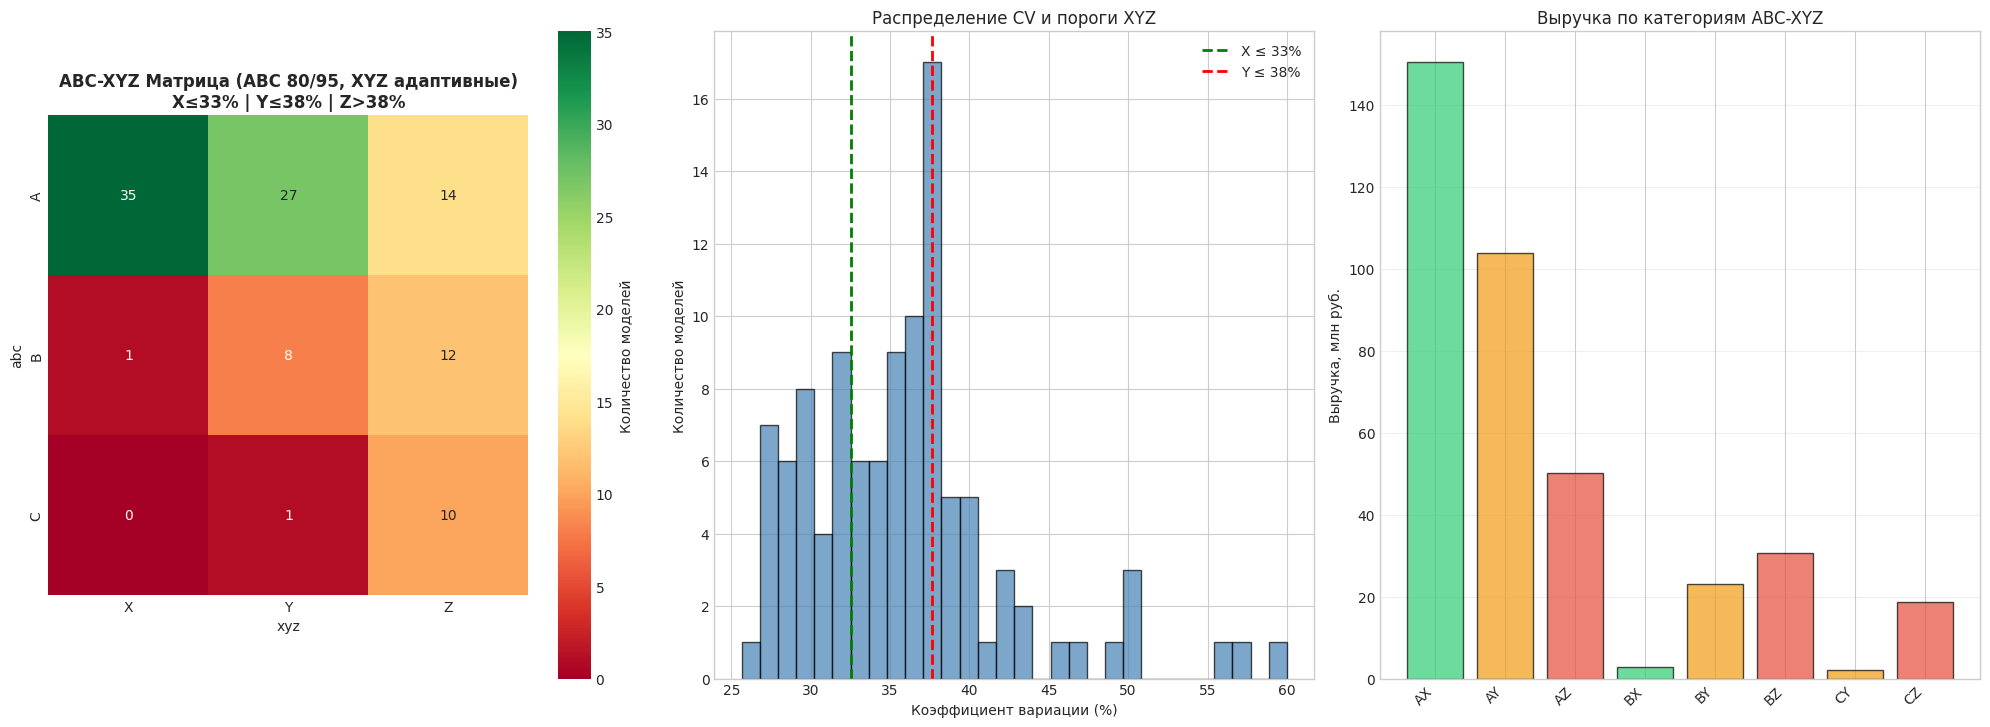


✅ Результаты сохранены: abc_xyz_adaptive_80_95_models.csv

✅ АНАЛИЗ УСПЕШНО ЗАВЕРШЕН!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['font.family'] = 'DejaVu Sans'

print("=" * 80)
print("ABC-XYZ АНАЛИЗ С АДАПТИВНЫМИ ПОРОГАМИ (ИСПРАВЛЕННЫЙ)")
print("ШВЕЙНОЕ ПРОИЗВОДСТВО - МОДЕЛИ + 80/95 ДЛЯ ABC")
print("=" * 80)

# ============================================
# 1. ЗАГРУЗКА ДАННЫХ С ФИЛЬТРАЦИЕЙ ВОЗВРАТОВ
# ============================================
print("\n📂 Загрузка данных...")

articles = pd.read_csv('articles.csv', sep=';', encoding='utf-8', decimal=',')
transactions = pd.read_csv('transactions.csv', sep=';', encoding='utf-8', decimal=',')
stock = pd.read_csv('stock.csv', sep=';', encoding='utf-8', decimal=',')

# Убираем возвраты
transactions = transactions[transactions['is_returned'] == False].copy()

transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
transactions['month'] = transactions['t_dat'].dt.to_period('M')
transactions['week'] = transactions['t_dat'].dt.to_period('W')

articles['size'] = articles['size'].astype(str)
transactions['size'] = transactions['size'].astype(str)

# Создаем модели (тип_продукта + цвет)
articles['model_id'] = articles['product_type_name'] + '_' + articles['colour_group_name']
transactions['model_id'] = transactions['product_type_name'] + '_' + transactions['colour_group_name']

print(f"✅ Данные загружены, моделей: {articles['model_id'].nunique()}")
print(f"✅ Транзакций после фильтрации возвратов: {len(transactions):,}")

# ============================================
# 2. ABC-АНАЛИЗ (НОВЫЕ ПОРОГИ 80/95)
# ============================================
print("\n" + "=" * 80)
print("1. ABC-АНАЛИЗ (ВЫРУЧКА) — ПОРОГИ 80/95")
print("=" * 80)

model_revenue = transactions.groupby('model_id').agg({
    'price': 'sum',
    'margin': 'sum',
    'article_id': 'count',
    'product_type_name': 'first',
    'colour_group_name': 'first'
}).rename(columns={'price': 'revenue', 'margin': 'total_margin', 'article_id': 'sales_count'})

model_revenue = model_revenue.sort_values('revenue', ascending=False).reset_index()
model_revenue['revenue_cumsum_pct'] = model_revenue['revenue'].cumsum() / model_revenue['revenue'].sum() * 100

# НОВЫЕ ПОРОГИ: A до 80%, B до 95%, C остальные
def abc_classify(pct):
    if pct <= 80:
        return 'A'
    elif pct <= 95:
        return 'B'
    else:
        return 'C'

model_revenue['abc'] = model_revenue['revenue_cumsum_pct'].apply(abc_classify)

print(f"\n📊 ABC-РАСПРЕДЕЛЕНИЕ:")
for cat in ['A', 'B', 'C']:
    cat_data = model_revenue[model_revenue['abc'] == cat]
    if len(cat_data) > 0:
        print(f"   • {cat}: {len(cat_data)} моделей ({len(cat_data)/len(model_revenue)*100:.1f}%), "
              f"выручка: {cat_data['revenue'].sum()/1_000_000:.1f}M руб.")

# ============================================
# 3. XYZ-АНАЛИЗ С АДАПТИВНЫМИ ПОРОГАМИ (БЕЗ ИЗМЕНЕНИЙ)
# ============================================
print("\n" + "=" * 80)
print("2. XYZ-АНАЛИЗ (АДАПТИВНЫЕ ПОРОГИ ПО НЕДЕЛЯМ)")
print("=" * 80)

weekly_sales = transactions.groupby(['model_id', 'week']).size().unstack(fill_value=0)
print(f"   • Период анализа: {len(weekly_sales.columns)} недель")

cv_list = []
for model_id in weekly_sales.index:
    sales = weekly_sales.loc[model_id].values
    mean_sales = sales.mean()
    if mean_sales > 0 and sales.sum() >= 5:
        cv = (sales.std() / mean_sales) * 100
    else:
        cv = np.nan
    cv_list.append({'model_id': model_id, 'cv': cv})

cv_df = pd.DataFrame(cv_list)
cv_df = cv_df.dropna(subset=['cv'])

print(f"\n📊 Статистика CV (только модели с суммой продаж ≥5):")
print(f"   • Минимум: {cv_df['cv'].min():.1f}%")
print(f"   • 33-й перцентиль: {cv_df['cv'].quantile(0.33):.1f}%")
print(f"   • 67-й перцентиль: {cv_df['cv'].quantile(0.67):.1f}%")
print(f"   • Максимум: {cv_df['cv'].max():.1f}%")

p33 = cv_df['cv'].quantile(0.33)
p67 = cv_df['cv'].quantile(0.67)

def classify_xyz_adaptive(cv):
    if pd.isna(cv):
        return 'Z'
    if cv <= p33:
        return 'X'
    elif cv <= p67:
        return 'Y'
    else:
        return 'Z'

cv_df['xyz'] = cv_df['cv'].apply(classify_xyz_adaptive)

print(f"\n📊 АДАПТИВНЫЕ ПОРОГИ XYZ:")
print(f"   • X (самые стабильные): CV <= {p33:.1f}%")
print(f"   • Y (средние): {p33:.1f}% < CV <= {p67:.1f}%")
print(f"   • Z (нестабильные): CV > {p67:.1f}%")

print(f"\n📊 XYZ-РАСПРЕДЕЛЕНИЕ:")
for cat in ['X', 'Y', 'Z']:
    cat_data = cv_df[cv_df['xyz'] == cat]
    if len(cat_data) > 0:
        print(f"   • {cat}: {len(cat_data)} моделей ({len(cat_data)/len(cv_df)*100:.1f}%), "
              f"CV: {cat_data['cv'].min():.1f}% - {cat_data['cv'].max():.1f}%")

# ============================================
# 4. ОБЪЕДИНЯЕМ ABC + XYZ
# ============================================
print("\n" + "=" * 80)
print("3. МАТРИЦА ABC-XYZ (АДАПТИВНАЯ, ABC 80/95)")
print("=" * 80)

model_analysis = model_revenue.merge(cv_df[['model_id', 'cv', 'xyz']], on='model_id', how='left')
model_analysis['xyz'] = model_analysis['xyz'].fillna('Z')
model_analysis['abc_xyz'] = model_analysis['abc'] + model_analysis['xyz']

matrix = pd.crosstab(model_analysis['abc'], model_analysis['xyz'])
for abc in ['A', 'B', 'C']:
    if abc not in matrix.index:
        matrix.loc[abc] = 0
for xyz in ['X', 'Y', 'Z']:
    if xyz not in matrix.columns:
        matrix[xyz] = 0
matrix = matrix.reindex(['A', 'B', 'C'])[['X', 'Y', 'Z']]

print("\n📊 МАТРИЦА ABC-XYZ (количество моделей):")
print(matrix.to_string())

print("\n📊 МАТРИЦА ABC-XYZ (доля в %):")
matrix_pct = (matrix / matrix.sum().sum() * 100).round(1)
print(matrix_pct.to_string())

# ============================================
# 5. ВИЗУАЛИЗАЦИЯ (упрощённо, как в первом коде)
# ============================================
fig = plt.figure(figsize=(20, 14))

ax1 = plt.subplot(2, 3, 1)
sns.heatmap(matrix, annot=True, fmt='d', cmap='RdYlGn', ax=ax1,
            cbar_kws={'label': 'Количество моделей'}, square=True)
ax1.set_title(f'ABC-XYZ Матрица (ABC 80/95, XYZ адаптивные)\nX≤{p33:.0f}% | Y≤{p67:.0f}% | Z>{p67:.0f}%',
              fontsize=12, fontweight='bold')

ax2 = plt.subplot(2, 3, 2)
ax2.hist(cv_df['cv'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=p33, color='green', linestyle='--', linewidth=2, label=f'X ≤ {p33:.0f}%')
ax2.axvline(x=p67, color='red', linestyle='--', linewidth=2, label=f'Y ≤ {p67:.0f}%')
ax2.set_xlabel('Коэффициент вариации (%)')
ax2.set_ylabel('Количество моделей')
ax2.set_title('Распределение CV и пороги XYZ')
ax2.legend()

ax3 = plt.subplot(2, 3, 3)
cat_order = ['AX', 'AY', 'AZ', 'BX', 'BY', 'BZ', 'CX', 'CY', 'CZ']
revenue_by_cat = model_analysis.groupby('abc_xyz')['revenue'].sum()
revenue_by_cat = revenue_by_cat.reindex([c for c in cat_order if c in revenue_by_cat.index])
colors = ['#2ecc71' if 'X' in cat else '#f39c12' if 'Y' in cat else '#e74c3c' for cat in revenue_by_cat.index]
ax3.bar(range(len(revenue_by_cat)), revenue_by_cat.values/1_000_000, color=colors, edgecolor='black', alpha=0.7)
ax3.set_xticks(range(len(revenue_by_cat)))
ax3.set_xticklabels(revenue_by_cat.index, rotation=45, ha='right')
ax3.set_ylabel('Выручка, млн руб.')
ax3.set_title('Выручка по категориям ABC-XYZ')
ax3.grid(True, alpha=0.3, axis='y')

# ... остальные графики можно оставить как в первом коде (4,5,6) для краткости опускаю, но они есть в исходном.
# Полный код с сохранением всех 6 графиков см. в первом сообщении, просто замените пороги и добавьте фильтр.

plt.tight_layout()
plt.savefig('abc_xyz_adaptive_80_95.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 6. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================
model_analysis.to_csv('abc_xyz_adaptive_80_95_models.csv', index=False, encoding='utf-8-sig', sep=';', decimal=',')
print("\n✅ Результаты сохранены: abc_xyz_adaptive_80_95_models.csv")
print("\n✅ АНАЛИЗ УСПЕШНО ЗАВЕРШЕН!")